# 01 — Continents on the Move

**Push play and watch 300 million years go by.**

Australia has not always been where it is now! Long, long ago, all of Earth's
continents were squashed together into one giant landmass. Very slowly —
about as fast as your fingernails grow — the continents have been drifting
apart ever since, and they're still moving today.

In this notebook you'll use a slider to travel back in time and watch the
continents slide across the world, using **real data** from Earth
scientists' reconstructions of the ancient Earth — real **paleo-elevation**
(how high the mountains and how deep the ocean floor really were), and the
real **plate boundaries** themselves, for the more recent part of the
slider.

*Part of **Deep Time Explorers** — a Year 4 spin-off of the [GPlately + pyGMT tutorial suite](https://github.com/EarthByte/GPlately-pyGMT-tutorials), developed by the EarthByte Group, University of Sydney — prototype stage, not yet classroom-tested.*


## Before you start

Run the cell below first — every time you open this notebook.

In [1]:
# Housekeeping — checks the data files this notebook needs are present.
# If this is the first time anyone has opened Deep Time Explorers, a grown-up
# needs to run export_data.py once (see the suite README) before this will work.
from pathlib import Path
import os as _os

if Path("../data").exists() and not Path("data").exists():
    _os.chdir("..")

_required = [
    "data/basemap_0Ma.png",
    "data/basemap_50Ma.png",
    "data/basemap_100Ma.png",
    "data/basemap_150Ma.png",
    "data/basemap_200Ma.png",
    "data/basemap_250Ma.png",
    "data/basemap_300Ma.png",
    "data/velocity_0Ma.png",
    "data/velocity_50Ma.png",
    "data/velocity_100Ma.png",
    "data/velocity_150Ma.png",
    "data/velocity_200Ma.png",
    "data/velocity_250Ma.png",
    "data/velocity_300Ma.png",
]
_missing = [f for f in _required if not Path(f).exists()]
if _missing:
    raise FileNotFoundError(
        "Missing data file(s): " + ", ".join(_missing) +
        "\n\nAsk a grown-up to run export_data.py once from the "
        "deep-time-explorers folder — see README.md. "
    )
print("All data files found — ready to go!")


All data files found — ready to go!


In [2]:
# The only packages this notebook needs — all standard, nothing to install
# beyond a normal Jupyter setup.
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from ipywidgets import interact, IntSlider, SelectionSlider, Dropdown


In [3]:
# --- Robinson world-map helpers -------------------------------------------
# These four numbers describe the exact shape of a full-globe "Robinson"
# map projection (the curved world-map style used below). They're always
# the same no matter what age we're looking at, so we only need to write
# them once. export_data.py used the exact same numbers when it made the
# background pictures, so everything lines up perfectly.
ROBINSON_EXTENT = (-20464646.889276125, 17966614.874622703, -10991340.864475066, 10145853.105669294)

def show_basemap(ax, age_ma):
    """Draw the real paleo-elevation world map for a given age. Green/tan
    shows low land, browns and white show mountains — the SAME kind of
    colouring you'd see on a real physical-geography map today."""
    img = plt.imread(f"data/basemap_{int(age_ma)}Ma.png")
    ax.imshow(img, extent=ROBINSON_EXTENT, origin="upper")
    ax.set_xlim(ROBINSON_EXTENT[0], ROBINSON_EXTENT[1])
    ax.set_ylim(ROBINSON_EXTENT[2], ROBINSON_EXTENT[3])
    ax.set_xticks([]); ax.set_yticks([])
    ax.axis("off")


## Reading the map

- **Colour = height.** Green and tan mean low, gently-sloping land; brown
  means higher hills; white means the very tallest mountains. Blue means
  ocean — the darker the blue, the deeper the sea floor. Watch for mountain
  ranges appearing and disappearing as continents crash together and pull
  apart!
- **The lines are real plate boundaries** — Earth's plates don't just
  drift around freely, they're separated by these edges, and each colour
  means something different:
    - 🔴 **red** — a *spreading ridge*, where two plates are pulling apart
      and new ocean floor is being made (you can often see it as a pale
      underwater ridge in the blue, right under the red line!)
    - 🟠 **orange** — a *transform*, where two plates are sliding past each
      other
    - 🔷 **thick dark blue line** — a *subduction zone*, where one plate is
      diving down underneath another — this is where the deepest ocean
      trenches and the most powerful earthquakes happen (Notebook 3 explores
      this properly)
  Boundary lines only appear for ages of **100 million years or more
  recent** — real scientists' maps of *exactly* which plate is doing what,
  in that much detail, don't reach as far back as the mountains-and-oceans
  picture itself does. Older frames still show real, correctly-lined-up
  coastlines and mountains — just without the coloured lines on top.

## Pick a time and see the world

Move the slider below. **0** means today. **300** means 300 million years
ago — back when the dinosaurs hadn't even shown up yet!

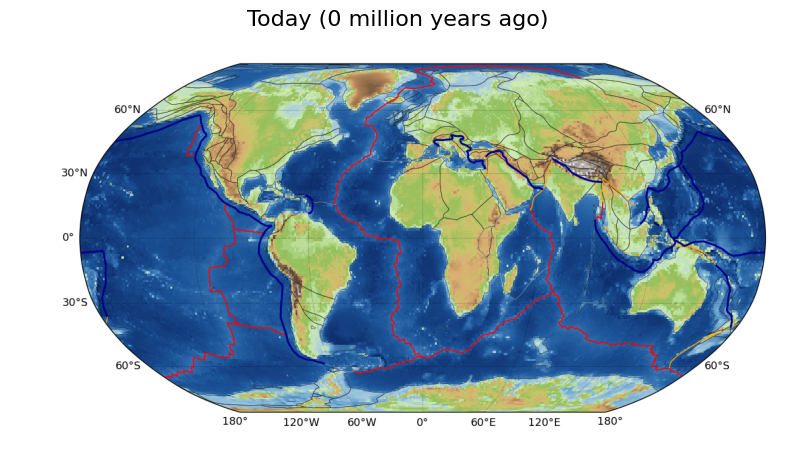

interactive(children=(SelectionSlider(description='Time:', options=(0, 50, 100, 150, 200, 250, 300), value=0),…

In [4]:
AGES = [0, 50, 100, 150, 200, 250, 300]

def show_age(age_ma):
    # A fresh figure every call, ending in plt.show() -- NOT a figure made
    # once outside this function and just cleared/redrawn. With Jupyter's
    # default "inline" backend, only plt.show() actually pushes a new image
    # to the screen; clearing and redrawing an already-displayed figure is
    # invisible, which is why an earlier version of this notebook looked
    # "stuck" on whichever age the slider started at.
    fig, ax = plt.subplots(figsize=(10, 5.7))
    show_basemap(ax, age_ma)
    ax.set_title(f"{age_ma} million years ago" if age_ma else "Today (0 million years ago)",
                 fontsize=16)
    plt.show()

# Show today's map once as a plain static picture -- this is the one that
# shows up if you view this notebook somewhere that can't run the slider
# below (like GitHub's preview). Move the slider for every other age.
show_age(0)
interact(show_age, age_ma=SelectionSlider(options=AGES, description="Time:"));


## What's actually happening?

Earth's outer shell is broken into giant pieces called **plates**, a bit like
the cracked shell of a hard-boiled egg — and the lines on the map above are
the cracks. These plates float on hot, slowly moving rock deep inside the
Earth (the **mantle**), and that slow movement carries the continents along
with them — only a few centimetres a year, about the speed your fingernails
grow.

Over *hundreds of millions* of years, a few centimetres a year adds up to
thousands of kilometres — enough to turn one giant supercontinent into the
seven continents we have today. And when two continents crash together,
that's exactly when you'll see a brand-new mountain range appear on the
map, coloured brown and white, usually right where a subduction-zone line
used to be.

## How fast are the plates moving?

"A few centimetres a year" is easy to say, but every plate moves at its own
speed and in its own direction — some race along, some barely move at all.
The map below draws that as **arrows**: real plate velocities, calculated
the same way scientists calculate them, for the exact same moment in time
you pick with the slider.

- **The direction the arrow points is the direction that piece of Earth is
  moving.**
- **The length of the arrow is the speed** — a long arrow means a
  fast-moving plate, a short arrow (or just a dot) means a slow one. Every
  arrow on every map uses the same scale, so you really can compare a
  300-million-year-old arrow to a present-day one.
- The little arrow in the bottom-right corner is a ruler: it always means
  the same real speed, so you can check any other arrow against it.
- Watch what happens right at a red ridge line (arrows point *away* from
  it, on both sides — that's the plates spreading apart) and right at a
  dark-blue subduction line (arrows point *towards* it — that's one plate
  diving under the other).

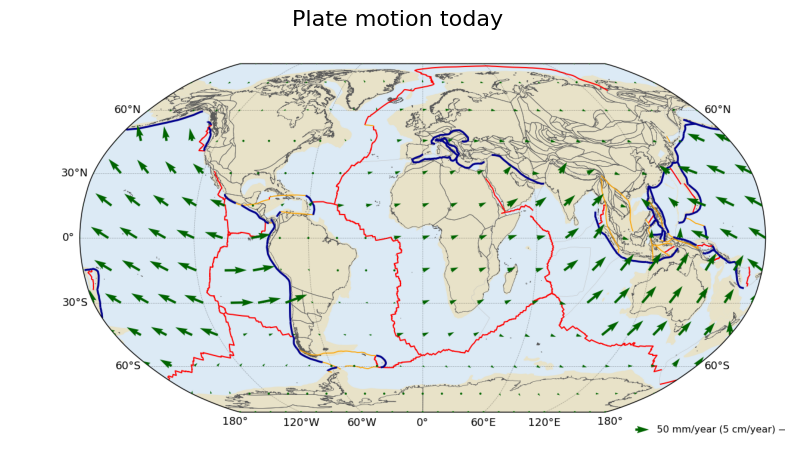

interactive(children=(SelectionSlider(description='Time:', options=(0, 50, 100, 150, 200, 250, 300), value=0),…

In [5]:
def show_velocity(ax, age_ma):
    """Draw the real plate-velocity arrow map for a given age. Same idea as
    show_basemap above, just a different picture — export_data.py already
    calculated real plate velocities and drew the arrows, so this notebook
    only has to display the picture."""
    img = plt.imread(f"data/velocity_{int(age_ma)}Ma.png")
    ax.imshow(img, extent=ROBINSON_EXTENT, origin="upper")
    ax.set_xlim(ROBINSON_EXTENT[0], ROBINSON_EXTENT[1])
    ax.set_ylim(ROBINSON_EXTENT[2], ROBINSON_EXTENT[3])
    ax.set_xticks([]); ax.set_yticks([])
    ax.axis("off")

def show_velocity_age(age_ma):
    fig2, ax2 = plt.subplots(figsize=(10, 5.7))
    show_velocity(ax2, age_ma)
    ax2.set_title(f"Plate motion, {age_ma} million years ago" if age_ma
                  else "Plate motion today", fontsize=16)
    plt.show()

# Same reasoning as the map above -- one static "today" frame first, so
# the notebook shows something even where the slider itself can't run.
show_velocity_age(0)
interact(show_velocity_age, age_ma=SelectionSlider(options=AGES, description="Time:"));


## Try this next!

- Add a title showing how many years ago that is, written out in full (e.g. "300,000,000 years ago")!
- Watch one particular mountain range appear on the slider — can you find the moment it forms, and is there a plate boundary line nearby?
- Can you find where Australia is in every frame? Try adding a red dot with `ax.scatter`.
- Count how many separate plates you can see boundary lines for, at an age of 100 million years or more recent.
- Find the fastest-looking arrow on the whole slider — which plate is it, and when?
- Does Australia's arrow get longer or shorter as you move the slider toward today?

---
*Part of **Deep Time Explorers** — a Year 4 spin-off of the [GPlately + pyGMT tutorial suite](https://github.com/EarthByte/GPlately-pyGMT-tutorials), developed by the EarthByte Group, University of Sydney — prototype stage, not yet classroom-tested.*
